In [2]:
import zipfile
import os

# Update these paths to match your local environment
zip_path = 'C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\Assignment Datasets\\Date_Fruit_Datasets.zip'
extract_to = 'C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\Assignment Datasets\\'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# List the extracted files
extracted_files = os.listdir(extract_to)
print("Extracted files:", extracted_files)

Extracted files: ['booking.csv', 'coffee.csv', 'Date_Fruit_Datasets', 'Date_Fruit_Datasets.zip', 'dosages.csv', 'Fertilizer.csv', 'health_outcome_dataset.csv', 'loan.csv', 'ObesityDataSet.csv', 'SteelPlant.csv', 'Teaching_Method.csv']


In [4]:
import os
import pandas as pd

df = pd.read_excel('C:\\Users\\njain121\\OneDrive - UHG\\Neha\\Scalar\\Assignment Datasets\\Date_Fruit_Datasets\\Date_Fruit_Datasets.xlsx')


In [5]:
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [6]:
class_counts = df.Class.value_counts()
classes = list(class_counts.index)
n_classes = len(classes)
print(f"we've got {n_classes} classes\n")
display(class_counts)

we've got 7 classes



Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64

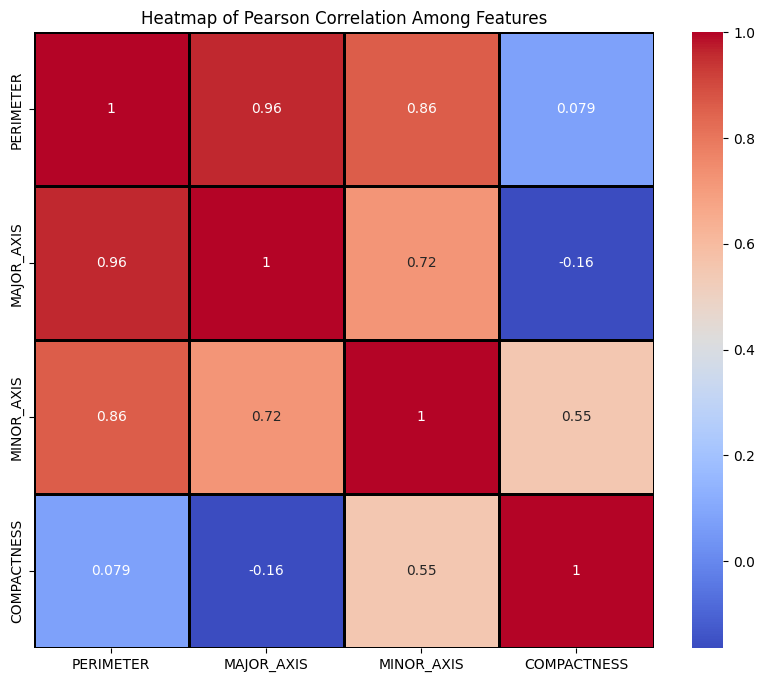

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Features to include in the correlation matrix
features = ['PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'COMPACTNESS']
# TODO: Compute the correlation matrix for the selected features
correlation_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
# TODO: Fill in the appropriate variable to visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=2, linecolor='black')
plt.title('Heatmap of Pearson Correlation Among Features')
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC  # TODO: Import the SVC (Support Vector Classifier) from sklearn.svm
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Preparing the feature and target variables
X = df.drop('Class', axis=1)
y = df['Class']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initializing the SVM model
svm = SVC(kernel='linear')  # TODO: Specify the kernel type for the SVC model

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # TODO: Apply the scaling to the training features
X_test_scaled = scaler.transform(X_test)  # TODO: Apply the scaling to the test features

# Training the SVM model
svm.fit(X_train_scaled, y_train)
predictions_scaled = svm.predict(X_test_scaled)  # TODO: Use the model to predict the test set

print("With Scaling:")
print(classification_report(y_test, predictions_scaled))  # TODO: Provide the true and predicted values to generate the classification report

With Scaling:
              precision    recall  f1-score   support

       BERHI       0.89      0.94      0.91        17
      DEGLET       0.73      0.79      0.76        28
       DOKOL       0.97      0.96      0.96        67
       IRAQI       0.87      0.95      0.91        21
      ROTANA       1.00      0.85      0.92        55
      SAFAVI       0.98      0.98      0.98        51
       SOGAY       0.74      0.84      0.79        31

    accuracy                           0.91       270
   macro avg       0.88      0.90      0.89       270
weighted avg       0.91      0.91      0.91       270



C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

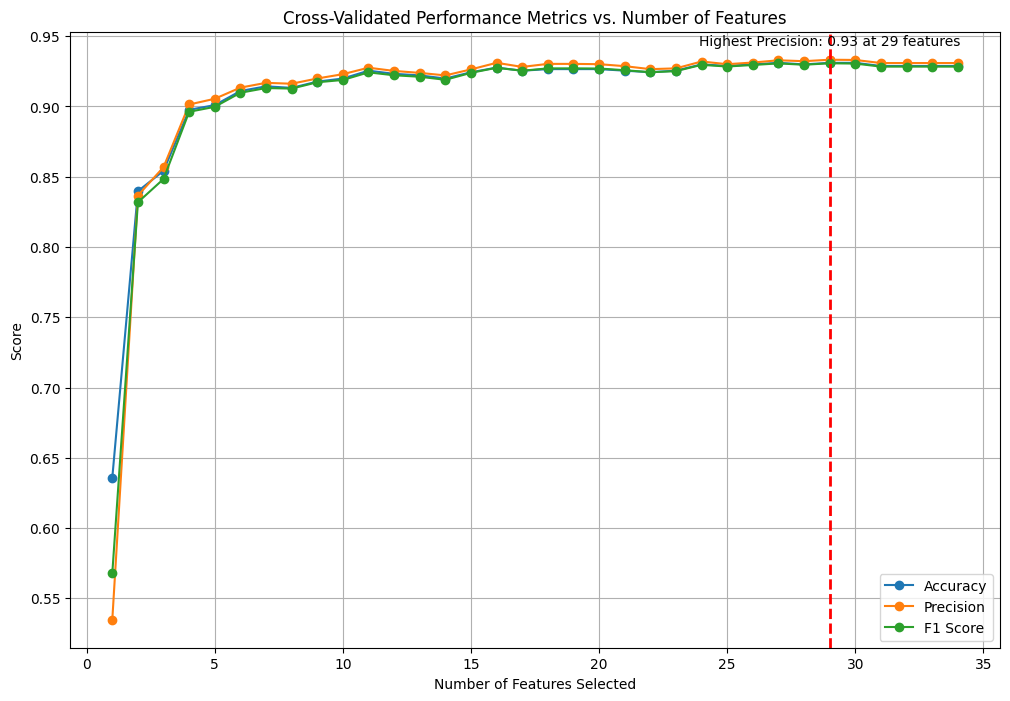

In [11]:
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load your data and separate into X (features) and y (target)
X = df.drop('Class', axis=1)
y = df['Class']

# Prepare cross-validation (use StratifiedKFold for classification tasks)
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Lists to store metrics
accuracies = []
precisions = []
f1_scores = []
feature_counts = range(1, X.shape[1] + 1)  # TODO: Define the range of feature counts to be selected

for n in feature_counts:
    # Feature scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)     # TODO: Apply scaling to the feature set

    # Feature selection
    selector = RFE(SVC(kernel='linear', random_state=42), n_features_to_select=n, step=1)   # TODO: Specify the number of features to select
    X_selected = selector.fit_transform(X_scaled, y)    # TODO: Fit and transform the data with the selector

    # SVM classifier
    svm = SVC(kernel='linear', random_state=10)   # TODO: Initialize the SVM model with appropriate parameters

    # Evaluate using cross-validation
    accuracy_scores = []
    precision_scores = []
    f1_scores_list = []
    for train_index, test_index in cv.split(X_selected, y):
        X_train_cv, X_test_cv = X_selected[train_index], X_selected[test_index]
        y_train_cv, y_test_cv = y[train_index], y[test_index]

        svm.fit(X_train_cv, y_train_cv)    # TODO: Fit the SVM model on the training data
        y_pred = svm.predict(X_test_cv)   # TODO: Make predictions on the test data
        
        accuracy_scores.append(accuracy_score(y_test_cv, y_pred))
        precision_scores.append(precision_score(y_test_cv, y_pred, average='weighted'))
        f1_scores_list.append(f1_score(y_test_cv, y_pred, average='weighted'))


    accuracies.append(np.mean(accuracy_scores))
    precisions.append(np.mean(precision_scores))
    f1_scores.append(np.mean(f1_scores_list))

# Plotting the results
plt.figure(figsize=(12, 8))
plt.plot(feature_counts, accuracies, label='Accuracy', marker='o')
plt.plot(feature_counts, precisions, label='Precision', marker='o')
plt.plot(feature_counts, f1_scores, label='F1 Score', marker='o')

# Highlight the point with highest precision
max_precision_index = np.argmax(precisions)
max_precision_feature_count = feature_counts[max_precision_index]
plt.scatter(max_precision_feature_count, precisions[max_precision_index], color='red')
plt.axvline(x=max_precision_feature_count, color='r', linestyle='--', lw=2)
plt.annotate(f'Highest Precision: {precisions[max_precision_index]:.2f} at {max_precision_feature_count} features',
             (max_precision_feature_count, precisions[max_precision_index]),
             textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel('Number of Features Selected')
plt.ylabel('Score')
plt.title('Cross-Validated Performance Metrics vs. Number of Features')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


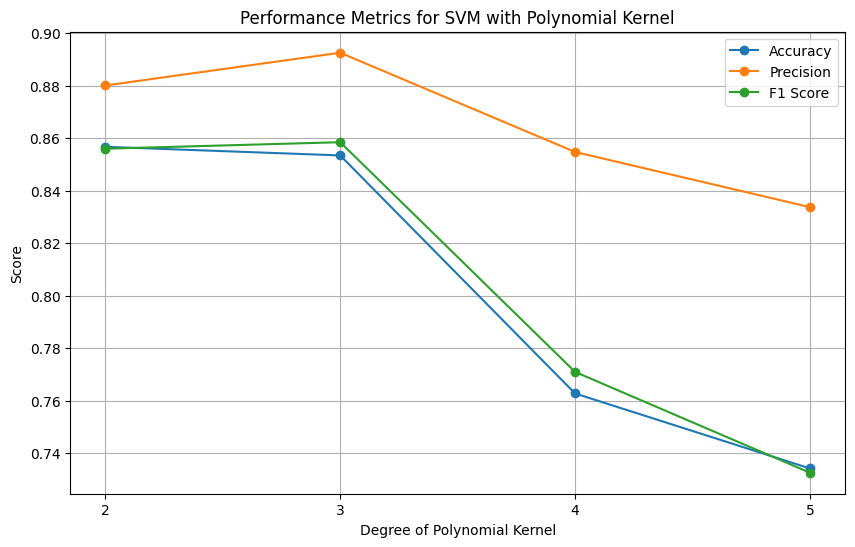

In [14]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Prepare cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Testing different degrees of the polynomial kernel
degrees = [2, 3, 4, 5]
accuracies = []
precisions = []
f1_scores = []

for degree in degrees:
    svm_poly = SVC(kernel='poly', degree=degree, gamma='scale', random_state=10)  # TODO: Specify the kernel type and degree parameter

    # Cross-validate the model
    accuracy = cross_val_score(svm_poly, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()  # TODO: Use the appropriate cross-validation function to get the mean accuracy
    precision = cross_val_score(svm_poly, X_train_scaled, y_train, cv=cv, scoring='precision_weighted').mean()  # TODO: Provide the feature set and call the appropriate method to get the mean precision
    f1 = cross_val_score(svm_poly, X_train_scaled, y_train, cv=cv, scoring='f1_weighted').mean()  # TODO: Specify the appropriate parameters for cross-validation

    # Store results for plotting
    accuracies.append(accuracy)
    precisions.append(precision)
    f1_scores.append(f1)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(degrees, accuracies, label='Accuracy', marker='o')
plt.plot(degrees, precisions, label='Precision', marker='o')
plt.plot(degrees, f1_scores, label='F1 Score', marker='o')
plt.xlabel('Degree of Polynomial Kernel')
plt.ylabel('Score')
plt.title('Performance Metrics for SVM with Polynomial Kernel')
plt.xticks(degrees)  # Set x-ticks to be the degrees for better readability
plt.legend()
plt.grid(True)
plt.show()

C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

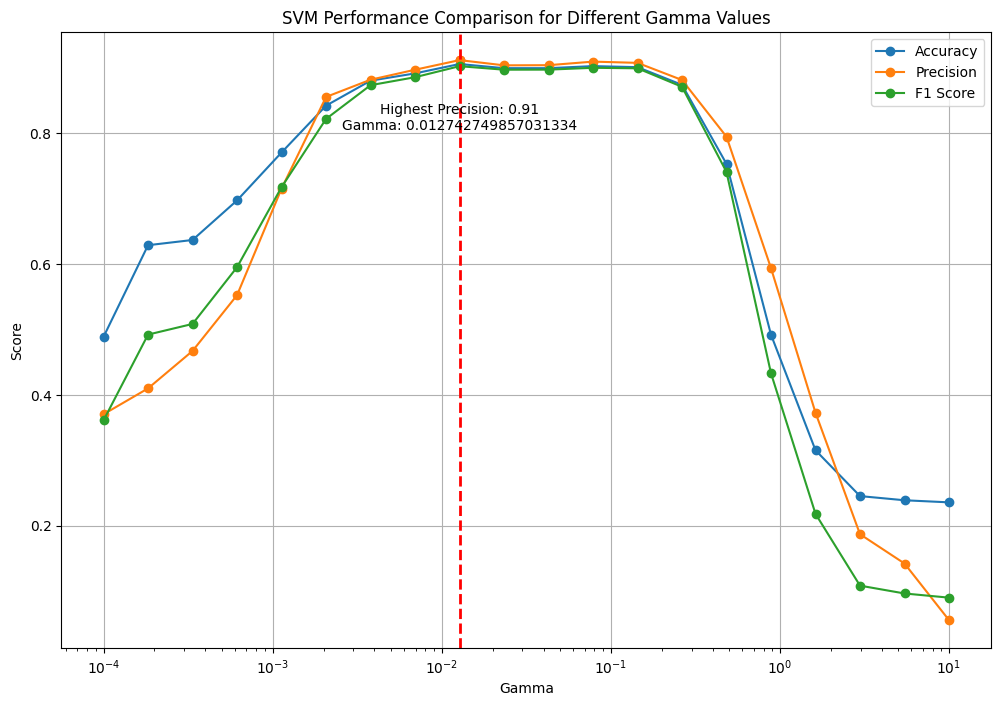

In [15]:
# Prepare cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Testing a new range of gamma values with more granularity
gamma_values = np.logspace(-4, 1, 20)  # Logarithmic scale from 10^-4 to 10^1
accuracies = []
precisions = []
f1_scores = []

for gamma in gamma_values:
    svm_rbf = SVC(kernel='rbf', gamma=gamma, random_state=10)  # TODO: Specify the correct kernel and parameter name for gamma

    # Cross-validate the model
    accuracy = np.mean(cross_val_score(svm_rbf, X_train_scaled, y_train, cv=cv, scoring='accuracy'))  # TODO: Use cross-validation to compute the mean accuracy
    precision = np.mean(cross_val_score(svm_rbf, X_train_scaled, y_train, cv=cv, scoring='precision_weighted'))  # TODO: Provide the feature set and compute the mean precision
    f1 = np.mean(cross_val_score(svm_rbf, X_train_scaled, y_train, cv=cv, scoring='f1_weighted'))  # TODO: Compute the mean F1 score using cross-validation

    # Store the scores
    accuracies.append(accuracy)
    precisions.append(precision)
    f1_scores.append(f1)

# Find the index and value of the highest precision
max_precision_index = np.argmax(precisions)  # TODO: Find the index of the maximum precision
max_precision_value = precisions[max_precision_index]
max_precision_gamma = gamma_values[max_precision_index]

# Plotting the results
plt.figure(figsize=(12, 8))
plt.plot(gamma_values, accuracies, label='Accuracy', marker='o')
plt.plot(gamma_values, precisions, label='Precision', marker='o')
plt.plot(gamma_values, f1_scores, label='F1 Score', marker='o')

# Highlighting the point with highest precision
plt.scatter(max_precision_gamma, max_precision_value, color='red')  # Highlight the point
plt.axvline(x=max_precision_gamma, color='r', linestyle='--', lw=2)  # Vertical line
plt.annotate(f'Highest Precision: {max_precision_value:.2f}\nGamma: {max_precision_gamma}',
             (max_precision_gamma, max_precision_value),
             textcoords="offset points", xytext=(0, -50), ha='center')

plt.xlabel('Gamma')
plt.ylabel('Score')
plt.title('SVM Performance Comparison for Different Gamma Values')
plt.xscale('log')  # Using logarithmic scale for gamma values
plt.legend()
plt.grid(True)
plt.show()

C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\njain121\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

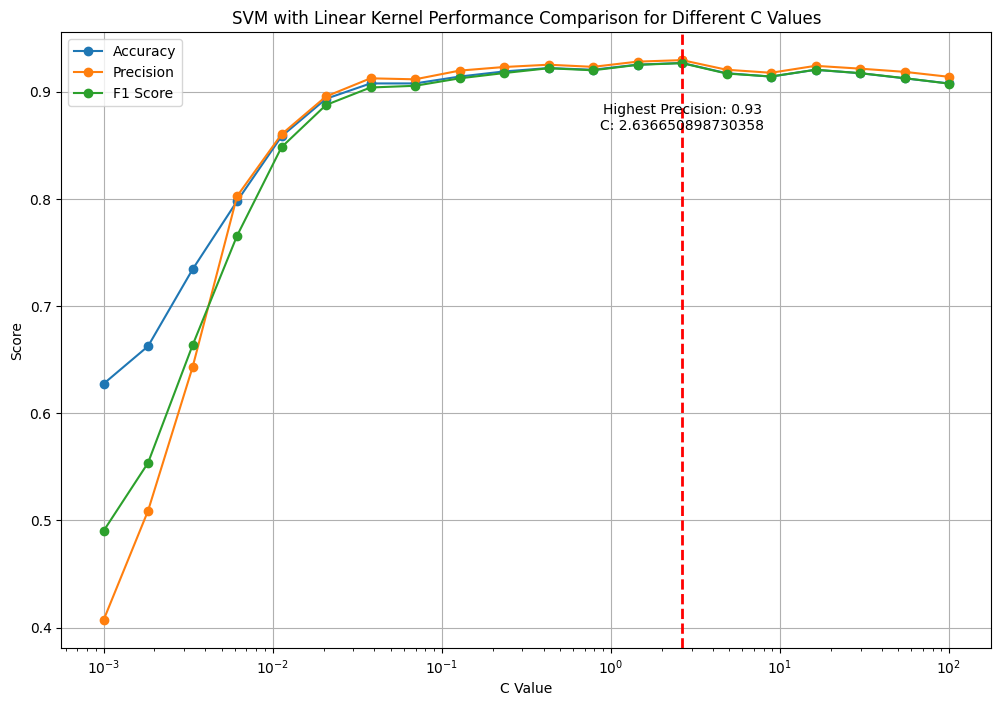

In [16]:
# Set up the RFE with SVM as the estimator and select the top 16 features
selector = RFE(SVC(kernel='linear', random_state=42), n_features_to_select=16, step=1)  # TODO: Specify the correct parameter names
X_train_rfe = selector.fit_transform(X_train_scaled, y_train)  # TODO: Fit and transform the training data with RFE
X_test_rfe = selector.transform(X_test_scaled)  # TODO: Transform the test data with RFE

# Prepare cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Testing different C values
c_values = np.logspace(-3, 2, 20)  # Explore a range of C values on a log scale
accuracies = []
precisions = []
f1_scores = []

for c in c_values:
    svm_linear = SVC(kernel='linear', C=c, random_state=42)  # TODO: Initialize the SVC model with a linear kernel and the C parameter

    # Cross-validate the model using only the selected features by RFE
    accuracy = np.mean(cross_val_score(svm_linear, X_train_rfe, y_train, cv=cv, scoring='accuracy'))  # TODO: Use cross_val_score to compute the mean accuracy
    precision = np.mean(cross_val_score(svm_linear, X_train_rfe, y_train, cv=cv, scoring='precision_weighted'))  # TODO: Compute the mean precision
    f1 = np.mean(cross_val_score(svm_linear, X_train_rfe, y_train, cv=cv, scoring='f1_weighted'))  # TODO: Compute the mean F1 score

    # Store the scores
    accuracies.append(accuracy)
    precisions.append(precision)
    f1_scores.append(f1)

# Find the index and value of the highest precision
max_precision_index = np.argmax(precisions)  # TODO: Find the index of the maximum precision
max_precision_value = precisions[max_precision_index]
max_precision_c = c_values[max_precision_index]

# Plotting the results
plt.figure(figsize=(12, 8))
plt.plot(c_values, accuracies, label='Accuracy', marker='o')
plt.plot(c_values, precisions, label='Precision', marker='o')
plt.plot(c_values, f1_scores, label='F1 Score', marker='o')

# Highlighting the point with highest precision
plt.scatter(max_precision_c, max_precision_value, color='red')  # Highlight the point
plt.axvline(x=max_precision_c, color='r', linestyle='--', lw=2)  # Vertical line
plt.annotate(f'Highest Precision: {max_precision_value:.2f}\nC: {max_precision_c}',
             (max_precision_c, max_precision_value),
             textcoords="offset points", xytext=(0, -50), ha='center')

plt.xlabel('C Value')
plt.ylabel('Score')
plt.title('SVM with Linear Kernel Performance Comparison for Different C Values')
plt.xscale('log')  # Using logarithmic scale for C values
plt.legend()
plt.grid(True)
plt.show()

---------------------------------------------------------------
Total Number of Support Vectors found are 15
---------------------------------------------------------------


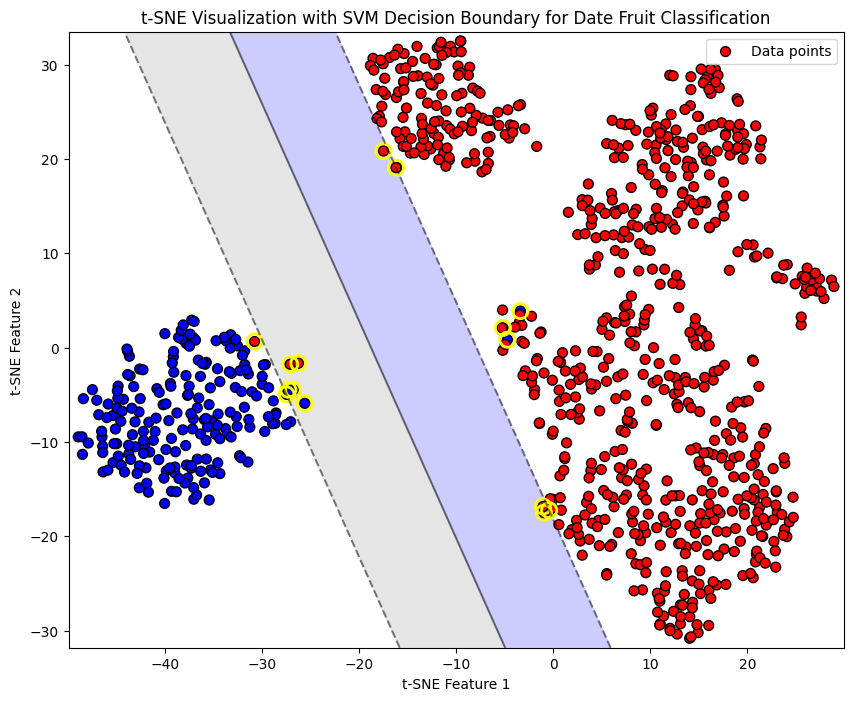

In [17]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# List of features
features = ['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY',
       'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO',
       'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2',
       'SHAPEFACTOR_3', 'SHAPEFACTOR_4', 'MeanRR', 'MeanRG', 'MeanRB',
       'StdDevRR', 'StdDevRG', 'StdDevRB', 'SkewRR', 'SkewRG', 'SkewRB',
       'KurtosisRR', 'KurtosisRG', 'KurtosisRB', 'EntropyRR', 'EntropyRG',
       'EntropyRB', 'ALLdaub4RR', 'ALLdaub4RG', 'ALLdaub4RB']

# Create a copy of the DataFrame
df_temp = df.copy()

# Select features and filter for two classes
df_temp['Class'] = df_temp['Class'].apply(lambda x: 'SAFAVI' if x == 'SAFAVI' else 'Other')

# Encoding classes
df_temp['Label'] = df_temp['Class'].map({'SAFAVI': 1, 'Other': 0})  # TODO: Use the appropriate method to map class labels to numerical values

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_temp[features])

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# SVM training
svm = SVC(kernel='linear', C=1.0)  # TODO: Initialize the SVC model with the correct parameters
svm.fit(X_tsne, df_temp['Label'])

# Support vectors
# Visit https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html to get the correct attribute for support vectors
support_vectors = svm.support_vectors_  

print(f'---------------------------------------------------------------')
print(f'Total Number of Support Vectors found are {len(support_vectors)}')
print(f'---------------------------------------------------------------')

# Create grid to plot decision boundaries
x_min, x_max = X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1
y_min, y_max = X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Plot decision boundary and margins
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])  # TODO: Use the decision function to predict decision boundaries
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 8))  # Define plot size here to ensure it encompasses all the elements
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.2, colors=['blue', 'grey', 'red'])  # Background color for decision areas
plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])  # Decision boundaries and margins

# Plot data points and support vectors
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_temp['Label'], cmap=ListedColormap(['#FF0000', '#0000FF']), s=50, edgecolors='k')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=120, facecolors='none', edgecolors='yellow', linewidths=2, label='Support vectors')

# Labels and title
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.title('t-SNE Visualization with SVM Decision Boundary for Date Fruit Classification')
plt.legend(handles=[scatter], labels=['Data points'], loc='upper right')

plt.show()

In [18]:
# Sample Data (Binary classification)
X = np.array([[2, 3], [3, 4], [1, 1], [4, 5], [6, 7]])
y = np.array([1, 1, -1, 1, -1])

data = pd.DataFrame(X, columns = ['f1', 'f2'])
data['y'] = y

data.head()

,f1,f2,y
0,2,3,1
1,3,4,1
2,1,1,-1
3,4,5,1
4,6,7,-1


In [19]:
import numpy as np

# Hinge Loss Implementation
def hinge_loss(X, y, weights, bias):
    """
    Compute hinge loss for a simple SVM model.
    Args:
        X (ndarray): Feature matrix.
        y (ndarray): Target vector.
        weights (ndarray): Weight vector.
        bias (float): Bias term.
    Returns:
        float: Hinge loss value.
    """
    margins = y * (np.dot(X,weights) + bias)  # TODO: Calculate the margins using a dot product of weights and features, and add the bias
    hinge_loss = np.maximum(0, 1 - margins)  # TODO: Apply the hinge loss formula: max(0, 1 - margin)
    return np.mean(hinge_loss)  # TODO: Return the mean or sum of the hinge loss values

# Example weights and bias
weights = np.array([0.5, 0.5])
bias = 0.0

# Compute Hinge Loss
loss = hinge_loss(X, y, weights, bias)
print(f'Hinge Loss: {loss:.4f}')

Hinge Loss: 1.9000
